In [1]:
# =========================================
# Ablation Study 1 — No Domain Alignment
# =========================================
!pip install --quiet --no-deps byol-pytorch==0.8.2 timm opencv-python-headless tqdm scikit-learn

import os, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===============================================
# Stage 1 — BYOL Pretraining (Self-Supervised)
# ===============================================
from byol_pytorch import BYOL

unlabeled_root = "/kaggle/input/dental-radiography-segmentation/Dental_Radiography/train"

class UnlabeledDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        for subdir, _, files in os.walk(root_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(subdir, f))
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

transform_unlabeled = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.ToTensor()
])

unlabeled_ds = UnlabeledDataset(unlabeled_root, transform=transform_unlabeled)
unlabeled_loader = DataLoader(unlabeled_ds, batch_size=32, shuffle=True, num_workers=4)
print("Unlabeled samples:", len(unlabeled_ds))

# EfficientNet-B0 backbone
backbone = models.efficientnet_b0(weights=None)
backbone.classifier = nn.Identity()

ssl_model = BYOL(backbone, image_size=224, projection_size=256, projection_hidden_size=1024).to(device)
opt_ssl = optim.Adam(ssl_model.parameters(), lr=1e-4)

epochs = 10  
for epoch in range(epochs):
    ssl_model.train()
    total_loss = 0
    for imgs in tqdm(unlabeled_loader, desc=f"BYOL Epoch {epoch+1}/{epochs}"):
        imgs = imgs.to(device)
        loss = ssl_model(imgs)
        opt_ssl.zero_grad()
        loss.backward()
        opt_ssl.step()
        total_loss += loss.item() * imgs.size(0)
    print(f"Epoch {epoch+1} loss = {total_loss/len(unlabeled_ds):.4f}")

torch.save(backbone.state_dict(), "efficientnet_b0_byol_backbone.pth")
print("✅ Saved BYOL-pretrained EfficientNet-B0 backbone.")

# ===============================================
# Stage 2 — Fine-tuning (Supervised)
# ===============================================
root_path = "/kaggle/input/dental-radiography-segmentation/Dental_Radiography"
train_dir = os.path.join(root_path, "train")
val_dir = os.path.join(root_path, "valid")
test_dir = os.path.join(root_path, "test")

transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
transform_eval = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform_train)
val_ds = datasets.ImageFolder(val_dir, transform=transform_eval)
test_ds = datasets.ImageFolder(test_dir, transform=transform_eval)
class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4)

backbone = models.efficientnet_b0(weights=None)
backbone.classifier = nn.Identity()

# Load BYOL pretrained weights if available
if os.path.exists("efficientnet_b0_byol_backbone.pth"):
    state = torch.load("efficientnet_b0_byol_backbone.pth", map_location=device)
    backbone.load_state_dict(state, strict=False)
    print("✅ Loaded BYOL pretrained EfficientNet-B0 backbone.")
else:
    print("⚠️ Using random initialization.")

head = nn.Sequential(
    nn.Linear(1280, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)

class FullModel(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head
    def forward(self, x):
        feats = self.backbone(x)
        if feats.dim() > 2:
            feats = torch.flatten(feats, 1)
        return self.head(feats)

model = FullModel(backbone, head).to(device)

# Freeze early layers to reduce overfitting
for name, p in model.backbone.named_parameters():
    if "features.6" not in name and "features.7" not in name:
        p.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"Fine-tune {epoch+1}/{epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    print(f"Epoch {epoch+1} acc={correct/total:.4f}")

torch.save(model.state_dict(), "finetuned_effnetb0_byol.pth")


Device: cuda
Unlabeled samples: 25136


BYOL Epoch 1/10: 100%|██████████| 786/786 [05:50<00:00,  2.24it/s]


Epoch 1 loss = 1.0948


BYOL Epoch 2/10: 100%|██████████| 786/786 [05:57<00:00,  2.20it/s]


Epoch 2 loss = 1.0346


...

Epoch 18 acc=0.8537


Fine-tune 19/20: 100%|██████████| 786/786 [01:01<00:00, 12.78it/s]


Epoch 19 acc=0.8539


Fine-tune 20/20: 100%|██████████| 786/786 [01:01<00:00, 12.76it/s]

Epoch 20 acc=0.8587


Device: cuda


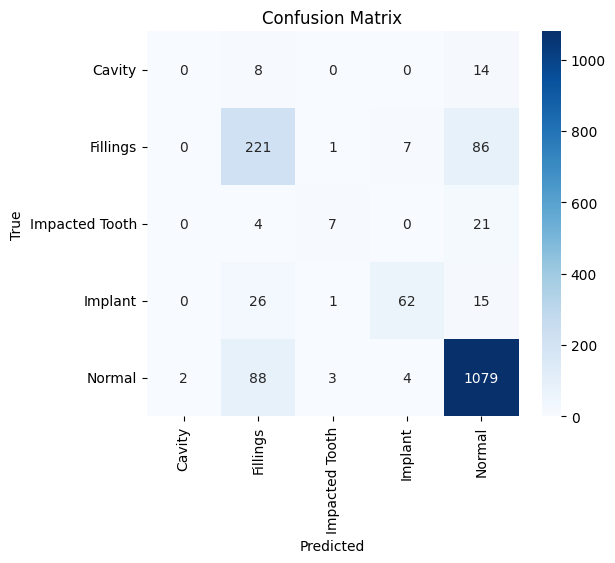


=== Ablation Study 1: No Domain Alignment ===
                precision    recall  f1-score   support

        Cavity     0.0000    0.0000    0.0000        22
      Fillings     0.6369    0.7016    0.6677       315
Impacted Tooth     0.5833    0.2188    0.3182        32
       Implant     0.8493    0.5962    0.7006       104
        Normal     0.8881    0.9175    0.9026      1176

      accuracy                         0.8302      1649
     macro avg     0.5915    0.4868    0.5178      1649
  weighted avg     0.8199    0.8302    0.8216      1649


=== Disease Category-wise Metrics ===
  Disease Category  Precision    Recall  F1-score  Support
0           Cavity   0.000000  0.000000  0.000000       22
1         Fillings   0.636888  0.701587  0.667674      315
2   Impacted Tooth   0.583333  0.218750  0.318182       32
3          Implant   0.849315  0.596154  0.700565      104
4           Normal   0.888066  0.917517  0.902551     1176

=== Specificity per Class ===
Cavity: 0.9988
Filling

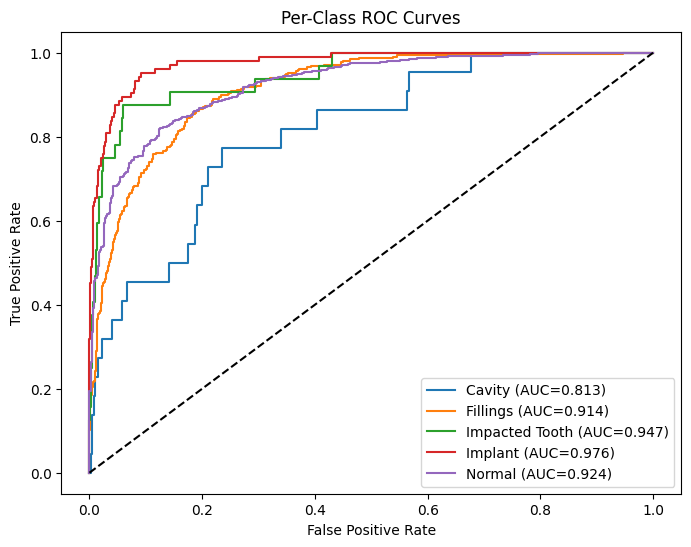

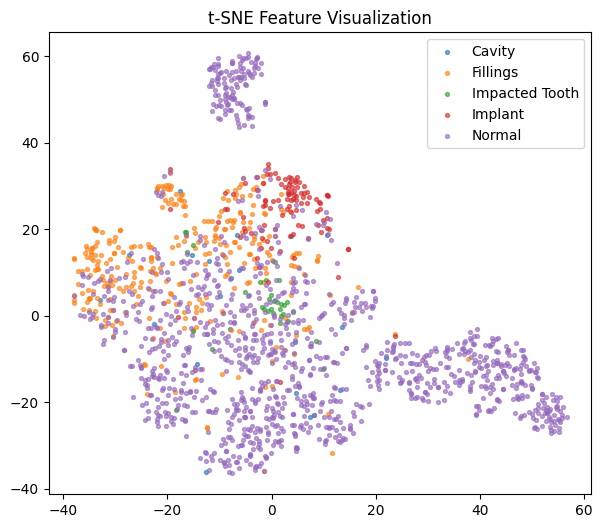


Overall Test Accuracy-No Domain Alignment: 0.8302


In [2]:
# ==============================
# Stage 3 — Evaluation ()
# ==============================

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------
# 1️⃣ Load test dataset
# ------------------------------
# Make sure test_ds is already defined
bs = 32
test_loader = DataLoader(test_ds, batch_size=bs, shuffle=True, num_workers=4)

# ------------------------------
# 2️⃣ Load trained model
# ------------------------------
ckpt = torch.load("/kaggle/working/finetuned_effnetb0_byol.pth", map_location=device)


# ------------------------------
# 3️⃣ Collect predictions & features
# ------------------------------
y_true = []
y_logits = []
feats_all = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        feats = model.backbone(imgs)
        if feats.dim() > 2:
            feats = torch.flatten(feats, 1)
        logits = model.head(feats)

        y_true.append(labels.cpu().numpy())
        y_logits.append(logits.cpu().numpy())
        feats_all.append(feats.cpu().numpy())

y_true = np.concatenate(y_true)
y_logits = np.concatenate(y_logits)
y_prob = F.softmax(torch.tensor(y_logits), dim=1).numpy()
y_pred = np.argmax(y_prob, axis=1)

# ------------------------------
# 4️⃣ Confusion matrix
# ------------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ------------------------------
# 5️⃣ Classification report & per-class metrics
# ------------------------------
print("\n=== Ablation Study 1: No Domain Alignment ===")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

# Optional: tabular per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
report_df = pd.DataFrame({
    "Disease Category": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
})
print("\n=== Disease Category-wise Metrics ===")
print(report_df)

# ------------------------------
# 6️⃣ Per-class specificity
# ------------------------------
specificity_per_class = []
for i in range(len(class_names)):
    TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    FP = cm[:, i].sum() - cm[i, i]
    specificity = TN / (TN + FP)
    specificity_per_class.append(specificity)

print("\n=== Specificity per Class ===")
for cname, spec in zip(class_names, specificity_per_class):
    print(f"{cname}: {spec:.4f}")

# ------------------------------
# 7️⃣ Per-class ROC curves
# ------------------------------
y_bin = label_binarize(y_true, classes=list(range(len(class_names))))
plt.figure(figsize=(8,6))
for i, cname in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cname} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Per-Class ROC Curves")
plt.legend()
plt.show()

# ------------------------------
# 8️⃣ Feature visualization (t-SNE)
# ------------------------------
feats_all = np.concatenate(feats_all)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
fe2 = tsne.fit_transform(feats_all)

plt.figure(figsize=(7,6))
for i, cname in enumerate(class_names):
    sel = y_true == i
    plt.scatter(fe2[sel,0], fe2[sel,1], label=cname, s=8, alpha=0.6)
plt.legend()
plt.title("t-SNE Feature Visualization")
plt.show()

# ------------------------------
# ✅ Done
# ------------------------------
acc = (y_pred == y_true).mean()
print(f"\nOverall Test Accuracy-No Domain Alignment: {acc:.4f}")
